# Fashion MNIST - Regularisering i CNN

Namn: Soroush Gholamreza

Fokusområde: Regularisering (Dropout och Early Stopping)

Syfte:
Att undersöka hur regularisering påverkar prestandan hos en CNN-modell för klassificering av klädesplagg i Fashion MNIST.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
import os
import gzip
import urllib.request
import numpy as np

DATA_DIR = "../data"

urls = {
    "train_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz"
}

os.makedirs(DATA_DIR, exist_ok=True)

for filename, url in urls.items():
    file_path = os.path.join(DATA_DIR, filename + ".gz")
    if not os.path.exists(file_path):
        print(f"Laddar ner {filename}...")
        urllib.request.urlretrieve(url, file_path)
    else:
        print(f"{filename} finns redan.")

def load_images(file_path):
    with gzip.open(file_path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_labels(file_path):
    with gzip.open(file_path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

x_train = load_images(os.path.join(DATA_DIR, "train_images.gz"))
y_train = load_labels(os.path.join(DATA_DIR, "train_labels.gz"))
x_test = load_images(os.path.join(DATA_DIR, "test_images.gz"))
y_test = load_labels(os.path.join(DATA_DIR, "test_labels.gz"))

print("Träningsbilder:", x_train.shape)
print("Testbilder:", x_test.shape)
print("Träningsetiketter:", y_train.shape)
print("Testetiketter:", y_test.shape)

Laddar ner train_images...
Laddar ner train_labels...
Laddar ner test_images...
Laddar ner test_labels...
Träningsbilder: (60000, 28, 28)
Testbilder: (10000, 28, 28)
Träningsetiketter: (60000,)
Testetiketter: (10000,)


## Notering om datasetkälla

Enligt uppgiftsbeskrivningen skulle Fashion MNIST laddas via:

```python
keras.datasets.fashion_mnist
```

Vid försök att använda denna metod uppstod följande fel:

```text
403 Forbidden

Access denied.

We're sorry, but this service is not available in your location.
```

Fashion MNIST som tillhannahålls via Keras/TensorFlow hämtas från Google lagringsserver (`storage.googleapis.com`). Eftersom jag genomför arbetet från Iran var denna tjänst inte tillgänglig från min nuvarande plats.

Jag testade även att hämta Fashion MNIST via OpenML, men nedladdningen misslyckades på grund av ett tekniskt fel vid hämtning av datasetets metadata.

För att kunna genomföra uppgiften användes därför Fashion MNIST från det officiella GitHub-repot för Fashion MNIST, publicerat av Zalando Research som skapade datasetet.

Det dataset som används i projektet är fortfarande Fashion MNIST med:

- 70 000 bilder totalt
- 60 000 träningsbilder
- 10 000 testbilder
- 10 klasser av klädesplagg
- bildstorlek 28x28 pixlar i gråskala

Endast nedladdningskällan skiljer sig åt. Datasetets innehåll, etikettter och användningsområde är identiska med den som laddas via Keras.

In [5]:
import pandas as pd

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

counts = np.bincount(y_train)

df_classes = pd.DataFrame({
    "Klass": class_names,
    "Antal bilder": counts
})

df_classes

,Klass,Antal bilder
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


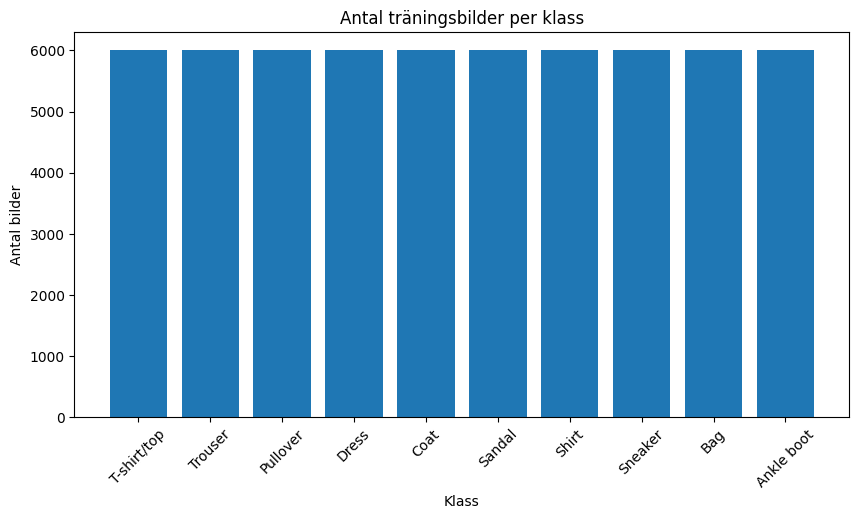

In [6]:
plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Antal träningsbilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

plt.xticks(rotation=45)

plt.show()

## Klassfördelning

För att undersöka om datasetet är balanserat analyserades antalet bilder i varje klass.

Resultatet visar att varje klass innehåller ungefär lika många bilder. Datasetet är därför välbalanserat och innehåller ingen tydlig klassobalans.

Detta är positivt eftersom modellen inte riskerar att gynna någon specifik klass på grund av att den förekommer oftare i träningsdatan.

En balanserad datasetfördelning gör det enklare att utvärdera modellens verkliga prestanda.

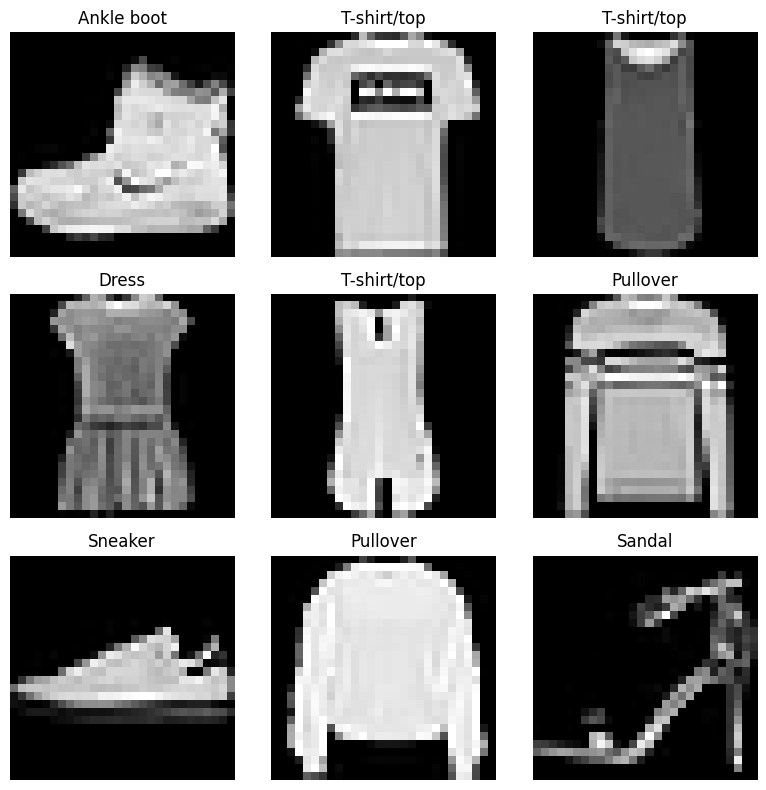

In [7]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minsta pixelvärde:", x_train.min())
print("Största pixelvärde:", x_train.max())

Minsta pixelvärde: 0.0
Största pixelvärde: 1.0


In [9]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Ny träningsform:", x_train.shape)
print("Ny testform:", x_test.shape)

Ny träningsform: (60000, 28, 28, 1)
Ny testform: (10000, 28, 28, 1)


## Datapreparering

Innan modellen kunde tränas behövde bilderna förberedas.

### Normalisering

Bilddata innehåller pixelvärden mellan 0 och 255. För att göra träningen mer stabil normaliserades bilderna genom att dividera varje pixelvärde med 255.

Efter normaliseringen ligger alla pixelvärden mellan 0 och 1.

### Omformning av data

Fashion MNIST består av gråskalbilder med storleken 28x28 pixlar.

Eftersom en CNN förväntar sig ett kannalvärde lades en kanal dimension till. Bildernas form ändrades därför från:

```text
(60000, 28, 28)
```

till:

```text
(60000, 28, 28, 1)
```

där den sista dimensionen representerar en gråskalskanal.

## Grundmodell

Som utgångspunkt skapades en enkel CNN.

CNN-modeller används ofta för bildklassificeringar eftersom dom är bra på att identifiera mönster, former och detaljer i bilderr.

Denna modell används som referensmodell för att senare kunna jämföra effekten av regularisering.

In [11]:
base_model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

base_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

base_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)